# FactorVAE — model visualization

This notebook shows:

1. **Layer summary** (`torchinfo`)
2. **Computation graph** (`torchview` + Graphviz, optional)
3. **Predictor attention** — per-factor attention weights over stocks (batch slice)
4. **Weight matrices** — `imshow` / histograms for selected linear layers

**Setup** (from repo root):

```bash
uv sync --extra viz
```

For PNG/SVG graphs you also need the **Graphviz** system install ([download](https://graphviz.org/download/)) so `dot` is on your `PATH`.

Run the notebook with the project root as the working directory (or adjust `PROJECT_ROOT` below).

In [ ]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from factor_vae.models.vae.factory import build_factor_vae

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

In [ ]:
config_path = PROJECT_ROOT / "config.yaml"
if not config_path.exists():
    raise FileNotFoundError(f"Missing {config_path} — set PROJECT_ROOT or run from repo root.")

with open(config_path, encoding="utf-8") as f:
    config = yaml.safe_load(f)

model_cfg = config["model"]
# Smaller settings speed up graph rendering while keeping the same architecture class
VIZ_MODEL_CFG = {
    "num_latent": model_cfg["num_latent"],
    "num_portfolio": model_cfg["num_portfolio"],
    "num_factor": model_cfg["num_factor"],
    "hidden_size": model_cfg["hidden_size"],
}
print("Viz model cfg:", VIZ_MODEL_CFG)

model = build_factor_vae(VIZ_MODEL_CFG).to(device)
model.eval()

test_cfg = config.get("test", {})
ckpt = PROJECT_ROOT / test_cfg.get("model_dir", "best_models") / test_cfg.get("model_name", "")
if ckpt.exists() and ckpt.suffix == ".pt":
    try:
        state = torch.load(ckpt, map_location=device, weights_only=True)
        model.load_state_dict(state, strict=False)
        print(f"Loaded partial/full checkpoint (strict=False): {ckpt.name}")
    except Exception as e:
        print(f"Checkpoint not applied (shape mismatch expected for small viz model): {e}")
else:
    print("No checkpoint loaded — using random init for visualization.")

Viz model cfg: {'num_latent': 158, 'num_portfolio': 128, 'num_factor': 32, 'hidden_size': 64}
Loaded partial/full checkpoint (strict=False): VAE-Revision2_factor_32_hdn_64_port_128_seed_42.pt


## 1. Layer summary (`torchinfo`)

In [ ]:
try:
    from torchinfo import summary
except ImportError:
    raise ImportError("Install viz extras: uv sync --extra viz")

B, T, L = 2, config["data"]["seq_len"], VIZ_MODEL_CFG["num_latent"]
x = torch.randn(B, T, L, device=device)
returns = torch.randn(B, 1, device=device)
summary(model, input_data=(x, returns), depth=4, col_names=("input_size", "output_size", "num_params"))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
FactorVAE                                [2, 20, 158]              --                        --
├─FeatureExtractor: 1-1                  [2, 20, 158]              [2, 64]                   --
│    └─LayerNorm: 2-1                    [2, 20, 158]              [2, 20, 158]              316
│    └─Linear: 2-2                       [2, 20, 158]              [2, 20, 158]              25,122
│    └─LeakyReLU: 2-3                    [2, 20, 158]              [2, 20, 158]              --
│    └─GRU: 2-4                          [2, 20, 158]              [2, 20, 64]               43,008
├─FactorEncoder: 1-2                     [2, 64]                   [32]                      --
│    └─Linear: 2-5                       [2, 64]                   [2, 128]                  8,320
│    └─Softmax: 2-6                      [2, 128]                  [2, 128]                  --
│    └─Linear: 2-7     

## 2. Computation graph (`torchview`)

Requires Graphviz **binaries** on `PATH`. If this fails, skip to the next sections.

In [ ]:
class VAELossWrapper(nn.Module):
    """Single-tensor input for graph tools that expect one argument."""

    def __init__(self, vae: nn.Module):
        super().__init__()
        self.vae = vae

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        returns = torch.zeros(x.shape[0], 1, device=x.device, dtype=x.dtype)
        return self.vae(x, returns)[0]


wrapped = VAELossWrapper(model).to(device)
graph_dir = PROJECT_ROOT / "notebooks" / "_graph_out"
graph_dir.mkdir(parents=True, exist_ok=True)

try:
    from torchview import draw_graph

    g = draw_graph(
        wrapped,
        input_size=(1, T, L),
        expand_nested=True,
        save_graph=True,
        filename="factor_vae_forward",
        directory=str(graph_dir),
    )
    print("Saved graph under:", graph_dir)
    display(g.visual_graph)
except Exception as e:
    print("Graph export skipped:", e)

NameError: name 'nn' is not defined

## 3. Predictor attention weights

Each factor head uses one `AttentionLayer`: weights are **length N** (batch = N stocks), softmax-normalized over stocks after ReLU. We plot a **subset of stocks** and **all factor heads** for one forward pass.

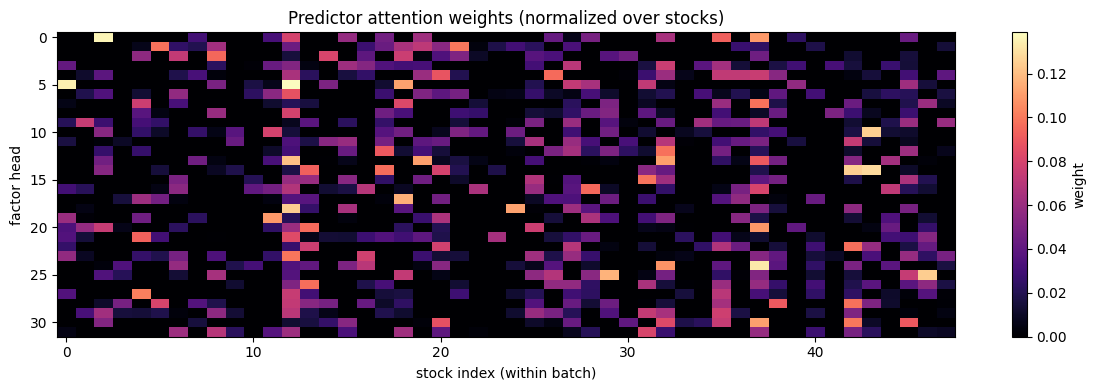

In [6]:
N = 64  # number of stocks in this fake batch
H = VIZ_MODEL_CFG["hidden_size"]
stock_latent = torch.randn(N, H, device=device)

pred = model.factor_predictor
pred.set_attention_capture(True)
with torch.no_grad():
    _ = pred(stock_latent)

weights = []
for i, layer in enumerate(pred.attention_layers):
    w = layer._last_attention_weights
    if w is None:
        raise RuntimeError(f"No captured weights for attention head {i}")
    weights.append(w.cpu().numpy())

W = np.stack(weights, axis=0)  # (num_factor, N)
max_stocks = 48
W_sub = W[:, :max_stocks]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(W_sub, aspect="auto", cmap="magma")
ax.set_xlabel("stock index (within batch)")
ax.set_ylabel("factor head")
ax.set_title("Predictor attention weights (normalized over stocks)")
plt.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()

pred.set_attention_capture(False)

## 4. Weight visualization

2D **`imshow`** for modest-sized `Linear` / `GRU` input weights; **histograms** for larger flatten-and-sample views. GRU weights are shown as the stacked input/hidden matrices when small enough.

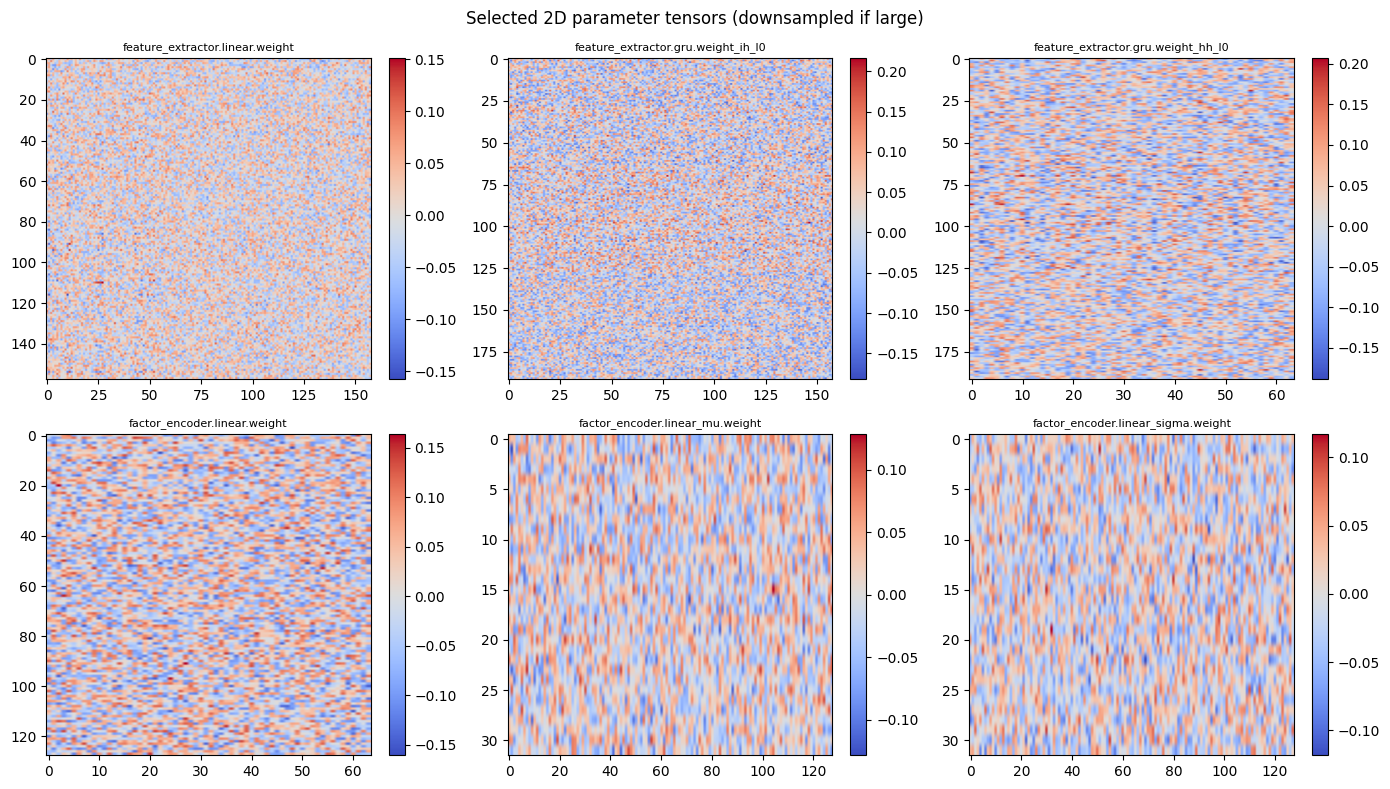

In [7]:
def downsample2d(w: np.ndarray, max_side: int = 128) -> np.ndarray:
    h, wd = w.shape
    if h <= max_side and wd <= max_side:
        return w
    # Simple block mean downsample
    fh, fw = max(h // max_side, 1), max(wd // max_side, 1)
    w = w[: h - h % fh, : wd - wd % fw]
    w = w.reshape(h // fh, fh, wd // fw, fw).mean(axis=(1, 3))
    return w


candidates = []
for name, p in model.named_parameters():
    if p.ndim != 2:
        continue
    if p.numel() > 500_000:
        continue
    candidates.append((name, p))

n_show = min(6, len(candidates))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, (name, p) in zip(axes, candidates[:n_show]):
    arr = downsample2d(p.detach().cpu().numpy())
    im = ax.imshow(arr, cmap="coolwarm", aspect="auto")
    ax.set_title(name[:50] + ("…" if len(name) > 50 else ""), fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
for j in range(n_show, len(axes)):
    axes[j].axis("off")
plt.suptitle("Selected 2D parameter tensors (downsampled if large)")
plt.tight_layout()
plt.show()

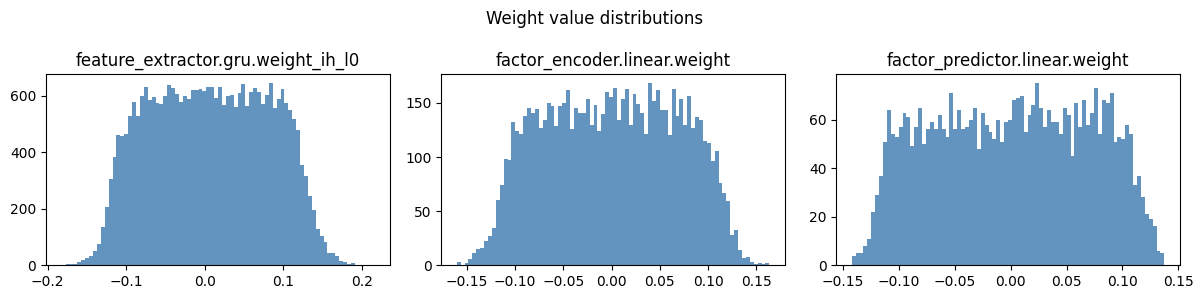

In [8]:
# Histograms for a few layers (any shape — flattened)
names = [
    "feature_extractor.gru.weight_ih_l0",
    "factor_encoder.linear.weight",
    "factor_predictor.linear.weight",
]
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3))
if len(names) == 1:
    axes = [axes]
for ax, key in zip(axes, names):
    found = False
    for name, p in model.named_parameters():
        if name == key:
            flat = p.detach().cpu().numpy().ravel()
            if flat.size > 50_000:
                flat = flat[np.linspace(0, flat.size - 1, 50_000, dtype=int)]
            ax.hist(flat, bins=80, color="steelblue", alpha=0.85)
            ax.set_title(key)
            found = True
            break
    if not found:
        ax.set_title(f"missing: {key}")
        ax.axis("off")
plt.suptitle("Weight value distributions")
plt.tight_layout()
plt.show()